# AgroOpt — Notebook 01: Exploratory Data Analysis (Revised)

**Objective**: Understand structure, quality, and relationships of every raw file before integration.

---

## Dataset Inventory

| # | File | Rows | Description |
|---|---|---|---|
| 1 | `crop_yield.csv` | 1 000 000 | **US-regional synthetic** agronomic observations |
| 2 | `yield.csv` | 56 717 | FAO raw yield (212 countries, 10 crops, 1961–2016) |
| 3 | `pesticides.csv` | 4 349 | FAO raw pesticide use (country/year) |
| 4 | `rainfall.csv` | 6 727 | FAO raw rainfall (country/year) |
| 5 | `temp.csv` | 71 311 | FAO temperature (country/year, 1849–2013) |
| 6 | `yield_df.csv` | 28 242 | **Pre-merged FAO** (files 2–5) — but contains a data bug |

## Critical Findings Summary

| Finding | Root Cause | Impact | Decision |
|---|---|---|---|
| `crop_yield` regions = US regions | Synthetic US data | Dataset is US-only; no country/year | Use as agronomic feature source only |
| USA absent from `yield_df` | Name mismatch: `"United States"` (rainfall) vs `"United States of America"` (pesticides/yield) → inner join fails | 168 rows lost (0.6%) | **Fix** name in Phase 2; rebuild from raw files |
| `yield_df` = pre-merge of files 2–5 | Same Kaggle dataset | Files 2–5 are redundant | Use raw files directly; **drop yield_df** |
| `crop_yield` 231 negative yields | Data artefact | 0.023% rows | Drop |
| `yield_df` 2 310 exact duplicates | Merge artefact | 8.18% rows | Drop |
| `temp` 6 958 exact duplicates | Source artefact | 9.76% rows | Drop |
| `rainfall` 780 nulls (11.6%) | Unmonitored years | `rainfall_mm` | Median imputation per country |
| `temp` 2 547 nulls (3.6%) | Pre-1961 gaps | `avg_temp` | Median imputation per country |

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data.load_data import load_all
from src.utils.logging import setup_logging

setup_logging(level='WARNING')

plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 14, 'axes.labelsize': 12})
sns.set_style('whitegrid')
Path('../data/processed').mkdir(parents=True, exist_ok=True)

datasets = load_all()
crop_yield = datasets['crop_yield']
yield_fao  = datasets['yield_fao']
pesticides = datasets['pesticides']
rainfall   = datasets['rainfall']
temp       = datasets['temp']
yield_df   = datasets['yield_df']

# Also load the raw FAO files under their original column names for name-mismatch analysis
raw_yield = pd.read_csv('../data/raw/yield.csv')
raw_pest  = pd.read_csv('../data/raw/pesticides.csv')
raw_rain  = pd.read_csv('../data/raw/rainfall.csv'); raw_rain.columns = raw_rain.columns.str.strip()

print('All datasets loaded.')

All datasets loaded.


---
## 1. Schema Inspection

In [2]:
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'  {name.upper()}  ({df.shape[0]:,} rows × {df.shape[1]} cols)')
    print(f'{"="*60}')
    info = pd.DataFrame({
        'dtype':   df.dtypes,
        'nulls':   df.isnull().sum(),
        'null_%':  (df.isnull().mean() * 100).round(2),
        'unique':  df.nunique(),
        'sample':  [str(df[c].dropna().iloc[0])[:40] if df[c].dropna().shape[0]>0 else 'N/A' for c in df.columns],
    })
    display(info)


  CROP_YIELD  (1,000,000 rows × 10 cols)


,dtype,nulls,null_%,unique,sample
region,object,0,0.0,4,West
soil_type,object,0,0.0,6,Sandy
crop,object,0,0.0,6,Cotton
rainfall_mm,float64,0,0.0,1000000,897.0772391101236
temperature_celsius,float64,0,0.0,1000000,27.676966373377603
fertilizer_used,bool,0,0.0,2,False
irrigation_used,bool,0,0.0,2,True
weather_condition,object,0,0.0,3,Cloudy
days_to_harvest,int64,0,0.0,90,122
yield_tons_per_hectare,float64,0,0.0,1000000,6.555816258223593



  YIELD_FAO  (56,717 rows × 4 cols)


,dtype,nulls,null_%,unique,sample
country,object,0,0.0,212,Afghanistan
crop,object,0,0.0,10,Maize
year,int64,0,0.0,56,1961
yield_hg_ha,int64,0,0.0,36815,14000



  PESTICIDES  (4,349 rows × 3 cols)


...

,dtype,nulls,null_%,unique,sample
country,object,0,0.0,217,Afghanistan
year,int64,0,0.0,31,1985
rainfall_mm,float64,780,11.6,172,327.0



  TEMP  (71,311 rows × 3 cols)


,dtype,nulls,null_%,unique,sample
country,object,0,0.00,137,Côte D'Ivoire
year,int64,0,0.00,271,1849
avg_temp,float64,2547,3.57,3303,25.58



  YIELD_DF  (28,242 rows × 7 cols)


,dtype,nulls,null_%,unique,sample
country,object,0,0.0,101,Albania
crop,object,0,0.0,10,Maize
year,int64,0,0.0,23,1990
yield_hg_ha,int64,0,0.0,11514,36613
rainfall_mm,float64,0,0.0,100,1485.0
pesticides_tonnes,float64,0,0.0,1673,121.0
avg_temp,float64,0,0.0,1831,16.37


---
## 2. File Lineage — The Two Families

```
Family A — "Agriculture Crop Yield" (synthetic, US-regional)
  └── crop_yield.csv     1 000 000 rows | Region: East/West/North/South

Family B — "Crop Yield Prediction Dataset" (FAO-based, international)
  ├── yield.csv          56 717 rows  ─┐
  ├── pesticides.csv      4 349 rows  ─┤ RAW building blocks
  ├── rainfall.csv        6 727 rows  ─┤
  ├── temp.csv           71 311 rows  ─┘
  └── yield_df.csv       28 242 rows    ← PRE-MERGED (but has a country-name bug)
```

> **Decision**: In Phase 2 we will **rebuild** the FAO merge from raw files to fix the bug, rather than using `yield_df.csv` directly.

---
## 3. FINDING: crop_yield is US-Regional Data

In [3]:
print('crop_yield regions:')
print(crop_yield['region'].value_counts().to_string())
print()
print('These correspond to the four US Census regions:')
print('  North  → Northern United States')
print('  South  → Southern United States')
print('  East   → Eastern United States')
print('  West   → Western United States')
print()
print('No country name, no year dimension — this is a US-centric synthetic dataset.')
print('It cannot be joined country-by-country with the FAO data.')

crop_yield regions:
region
North    250173
West     250074
South    250054
East     249699

These correspond to the four US Census regions:
  North  → Northern United States
  South  → Southern United States
  East   → Eastern United States
  West   → Western United States

No country name, no year dimension — this is a US-centric synthetic dataset.
It cannot be joined country-by-country with the FAO data.


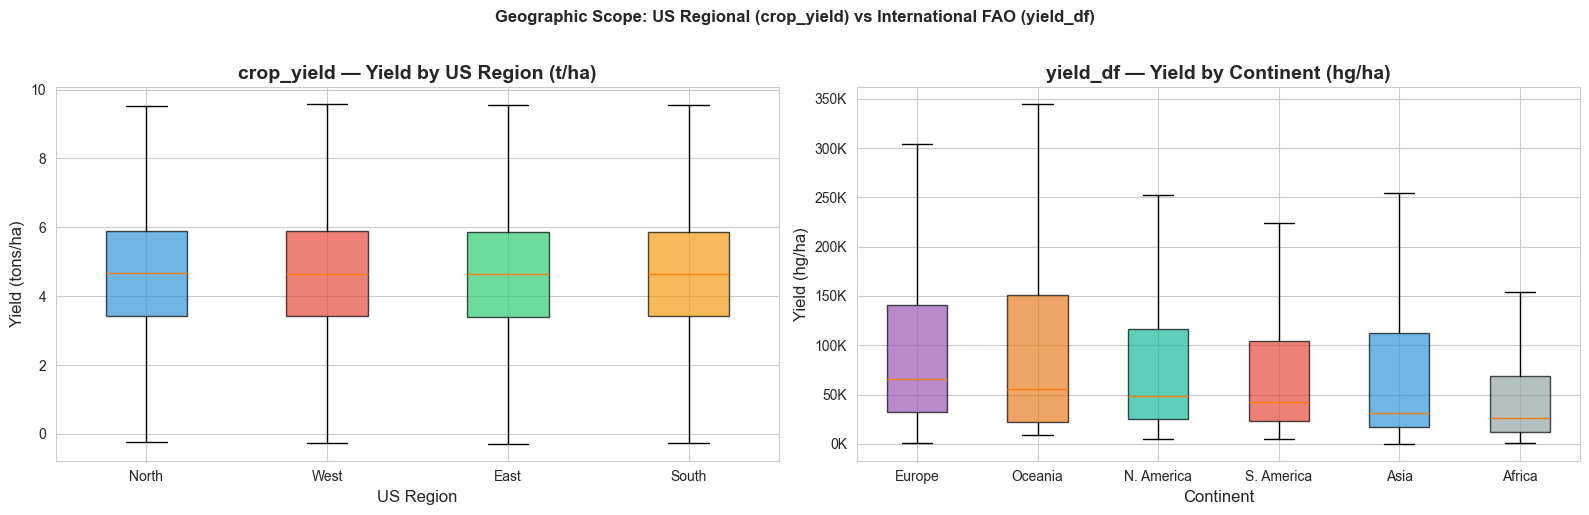

Insight: crop_yield (US) and yield_df (international, excl. US) cover DIFFERENT geographies.
USA is the only major agricultural producer absent from yield_df.


In [4]:
# Visual: crop_yield feature space vs FAO feature space
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: crop_yield — yield by US region
region_order = crop_yield.groupby('region')['yield_tons_per_hectare'].median().sort_values(ascending=False).index.tolist()
region_data  = [crop_yield[crop_yield['region']==r]['yield_tons_per_hectare'].values for r in region_order]
bp = axes[0].boxplot(region_data, labels=region_order, showfliers=False, patch_artist=True)
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title('crop_yield — Yield by US Region (t/ha)', fontweight='bold')
axes[0].set_xlabel('US Region')
axes[0].set_ylabel('Yield (tons/ha)')

# Right: yield_df — yield by FAO region (continent grouping)
continent_map = {
    'Albania':'Europe','Algeria':'Africa','Angola':'Africa','Argentina':'S. America',
    'Armenia':'Asia','Australia':'Oceania','Austria':'Europe','Azerbaijan':'Asia',
    'Bahamas':'N. America','Bahrain':'Asia','Bangladesh':'Asia','Belarus':'Europe',
    'Belgium':'Europe','Botswana':'Africa','Brazil':'S. America','Bulgaria':'Europe',
    'Burkina Faso':'Africa','Burundi':'Africa','Cameroon':'Africa','Canada':'N. America',
    'Chile':'S. America','Colombia':'S. America','Croatia':'Europe','Denmark':'Europe',
    'Dominican Republic':'N. America','Ecuador':'S. America','Egypt':'Africa',
    'El Salvador':'N. America','Eritrea':'Africa','Estonia':'Europe','Finland':'Europe',
    'France':'Europe','Germany':'Europe','Ghana':'Africa','Greece':'Europe',
    'Guatemala':'N. America','Guinea':'Africa','Guyana':'S. America','Haiti':'N. America',
    'Honduras':'N. America','Hungary':'Europe','India':'Asia','Indonesia':'Asia',
    'Iraq':'Asia','Ireland':'Europe','Italy':'Europe','Jamaica':'N. America',
    'Japan':'Asia','Kazakhstan':'Asia','Kenya':'Africa','Latvia':'Europe',
    'Lebanon':'Asia','Lesotho':'Africa','Libya':'Africa','Lithuania':'Europe',
    'Madagascar':'Africa','Malawi':'Africa','Malaysia':'Asia','Mali':'Africa',
    'Mauritania':'Africa','Mauritius':'Africa','Mexico':'N. America','Montenegro':'Europe',
    'Morocco':'Africa','Mozambique':'Africa','Namibia':'Africa','Nepal':'Asia',
    'Netherlands':'Europe','New Zealand':'Oceania','Nicaragua':'N. America',
    'Niger':'Africa','Norway':'Europe','Pakistan':'Asia','Papua New Guinea':'Oceania',
    'Peru':'S. America','Poland':'Europe','Portugal':'Europe','Qatar':'Asia',
    'Romania':'Europe','Rwanda':'Africa','Saudi Arabia':'Asia','Senegal':'Africa',
    'Slovenia':'Europe','South Africa':'Africa','Spain':'Europe','Sri Lanka':'Asia',
    'Sudan':'Africa','Suriname':'S. America','Sweden':'Europe','Switzerland':'Europe',
    'Tajikistan':'Asia','Thailand':'Asia','Tunisia':'Africa','Turkey':'Asia',
    'Uganda':'Africa','Ukraine':'Europe','United Kingdom':'Europe','Uruguay':'S. America',
    'Zambia':'Africa','Zimbabwe':'Africa',
    'Central African Republic':'Africa'
}
yd_plot = yield_df.drop_duplicates().copy()
yd_plot['continent'] = yd_plot['country'].map(continent_map).fillna('Other')
cont_order = yd_plot.groupby('continent')['yield_hg_ha'].median().sort_values(ascending=False).index.tolist()
cont_data  = [yd_plot[yd_plot['continent']==c]['yield_hg_ha'].values for c in cont_order]
bp2 = axes[1].boxplot(cont_data, labels=cont_order, showfliers=False, patch_artist=True)
palette = ['#9b59b6','#e67e22','#1abc9c','#e74c3c','#3498db','#95a5a6']
for patch, color in zip(bp2['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('yield_df — Yield by Continent (hg/ha)', fontweight='bold')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Yield (hg/ha)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.suptitle('Geographic Scope: US Regional (crop_yield) vs International FAO (yield_df)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_01_geographic_scope.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: crop_yield (US) and yield_df (international, excl. US) cover DIFFERENT geographies.')
print('USA is the only major agricultural producer absent from yield_df.')

---
## 4. FINDING: USA Absent from yield_df — Root Cause

In [5]:
# Country name for USA across all 4 raw FAO files
usa_in_yield = raw_yield[raw_yield['Area'].str.contains('United States', case=False, na=False)]['Area'].unique()
usa_in_pest  = raw_pest[raw_pest['Area'].str.contains('United States', case=False, na=False)]['Area'].unique()
usa_in_rain  = raw_rain[raw_rain['Area'].str.contains('United States', case=False, na=False)]['Area'].unique()
usa_in_yd    = yield_df[yield_df['country'].str.contains('United States', case=False, na=False)]['country'].unique()

print('Country name used for USA across raw files:')
print(f'  yield.csv       → {usa_in_yield}')
print(f'  pesticides.csv  → {usa_in_pest}')
print(f'  rainfall.csv    → {usa_in_rain}')
print(f'  yield_df.csv    → {usa_in_yd}  (absent!)')
print()
print('ROOT CAUSE:')
print('  When yield_df.csv was originally built, an INNER JOIN was performed on country name.')
print('  pesticides.csv used  : "United States of America"')
print('  rainfall.csv used    : "United States"')
print('  → Name mismatch → USA row dropped silently.')

Country name used for USA across raw files:
  yield.csv       → ['United States of America']
  pesticides.csv  → ['United States of America']
  rainfall.csv    → ['United States']
  yield_df.csv    → []  (absent!)

ROOT CAUSE:
  When yield_df.csv was originally built, an INNER JOIN was performed on country name.
  pesticides.csv used  : "United States of America"
  rainfall.csv used    : "United States"
  → Name mismatch → USA row dropped silently.


In [6]:
# How many USA rows were lost?
usa_fao_window = raw_yield[
    (raw_yield['Area'] == 'United States of America') &
    (raw_yield['Year'].between(1990, 2013))
]

current_rows = len(yield_df)
lost_rows    = len(usa_fao_window)
fixed_total  = current_rows + lost_rows

print(f'USA rows in FAO yield.csv (1990–2013): {lost_rows}')
print(f'Crops covered by USA in that period:   {sorted(usa_fao_window["Item"].unique())}')
print()
print(f'Current yield_df rows: {current_rows:,}')
print(f'USA rows missing:      {lost_rows:,}   ({lost_rows/fixed_total*100:.1f}% of corrected dataset)')
print(f'Corrected total:       {fixed_total:,}')
print()
print('USA mean yields (hg/ha, FAO 1990–2013):')
print(usa_fao_window.groupby('Item')['Value'].mean().round(0).sort_values(ascending=False).to_string())

USA rows in FAO yield.csv (1990–2013): 168
Crops covered by USA in that period:   ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat']

Current yield_df rows: 28,242
USA rows missing:      168   (0.6% of corrected dataset)
Corrected total:       28,410

USA mean yields (hg/ha, FAO 1990–2013):
Item
Potatoes          409929.0
Sweet potatoes    190660.0
Maize              85946.0
Rice, paddy        72048.0
Sorghum            39692.0
Wheat              27588.0
Soybeans           26338.0


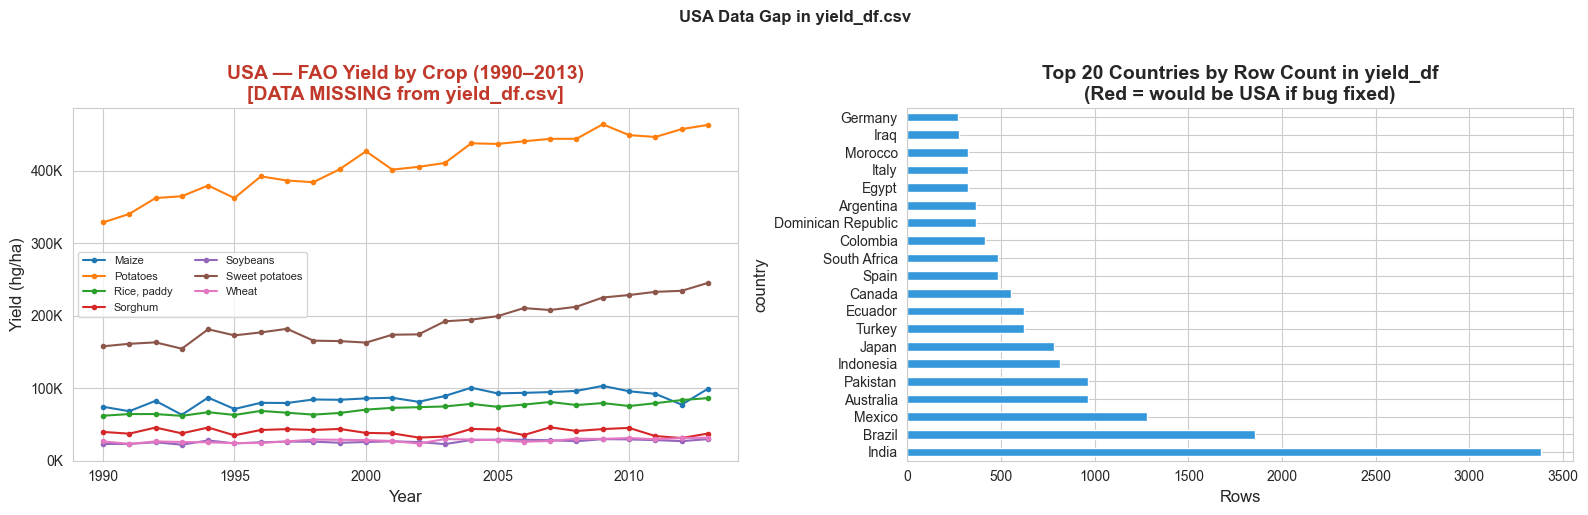

In [7]:
# Visualise the missing USA data
usa_yield_ts = raw_yield[
    (raw_yield['Area'] == 'United States of America') &
    (raw_yield['Year'].between(1990, 2013))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Yield trend for each crop in USA
for item in sorted(usa_yield_ts['Item'].unique()):
    subset = usa_yield_ts[usa_yield_ts['Item']==item]
    axes[0].plot(subset['Year'], subset['Value'], marker='o', markersize=3, label=item)
axes[0].set_title('USA — FAO Yield by Crop (1990–2013)\n[DATA MISSING from yield_df.csv]', fontweight='bold', color='#c0392b')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Yield (hg/ha)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
axes[0].legend(fontsize=8, ncol=2)

# Bar: coverage per country — show top 20 + USA vs mean
country_rows = yield_df.drop_duplicates()['country'].value_counts()
top20 = country_rows.nlargest(20)
colors_bar = ['#c0392b' if c == 'United States of America' else '#3498db' for c in top20.index]
top20.plot(kind='barh', ax=axes[1], color=colors_bar)
axes[1].set_title('Top 20 Countries by Row Count in yield_df\n(Red = would be USA if bug fixed)', fontweight='bold')
axes[1].set_xlabel('Rows')

plt.suptitle('USA Data Gap in yield_df.csv', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/eda_02_usa_data_gap.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Missing Value Analysis

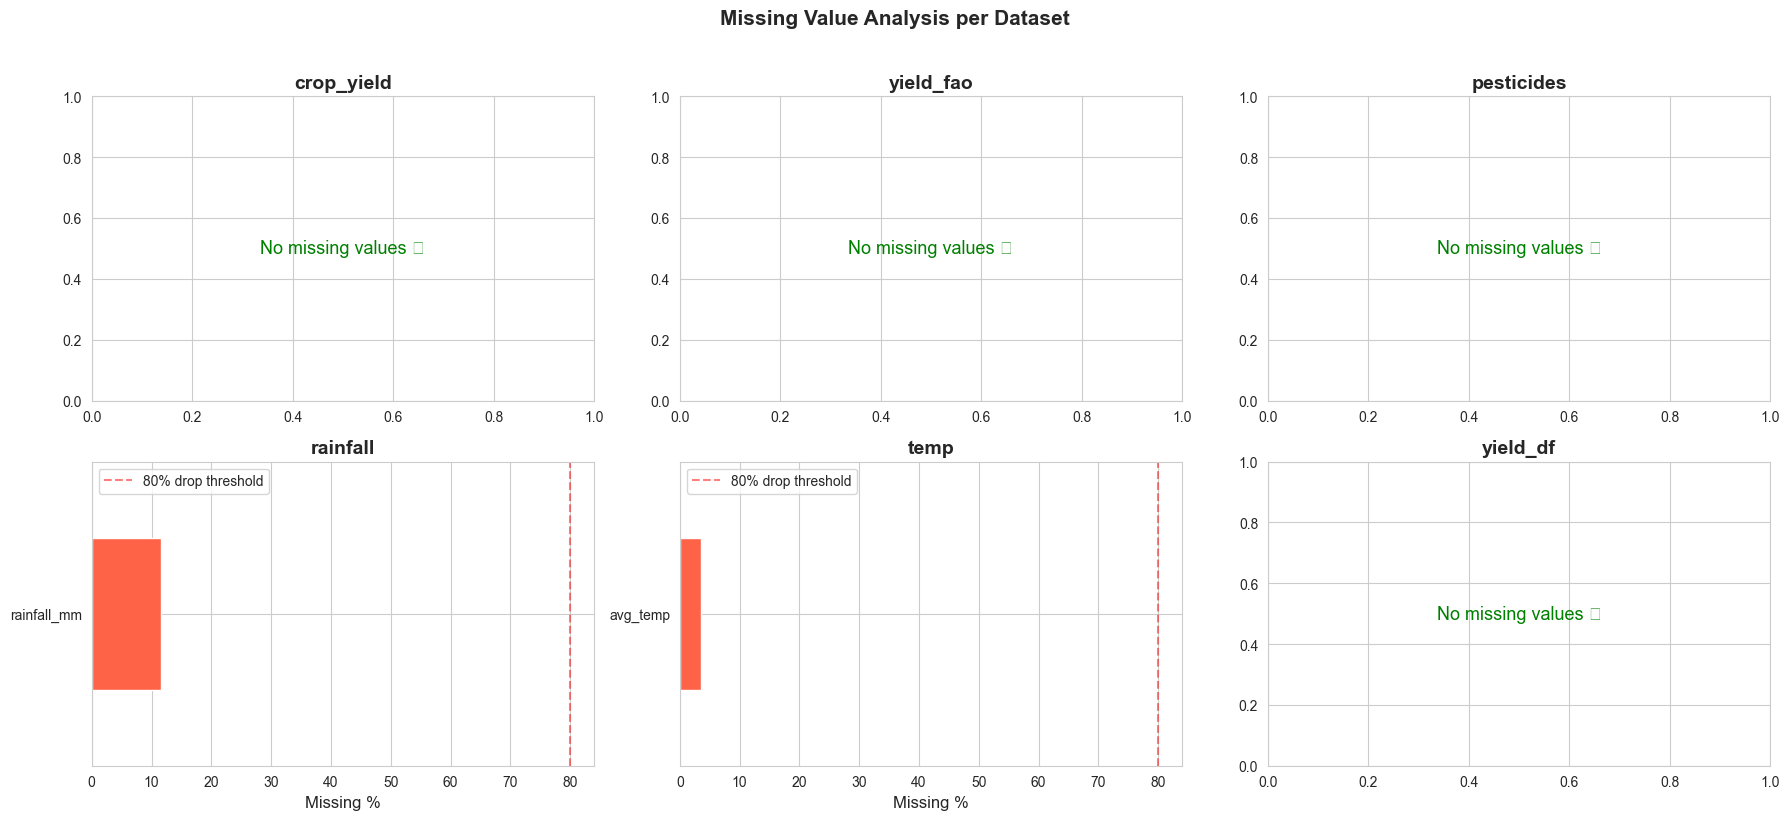

Decisions:
  rainfall → rainfall_mm  11.6% → median imputation per country  (no rows dropped)
  temp     → avg_temp      3.6% → median imputation per country  (no rows dropped)
  No column exceeds 80% threshold.


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    if null_pct.max() == 0:
        ax.text(0.5, 0.5, 'No missing values ✅', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color='green')
    else:
        null_pct[null_pct > 0].plot(kind='barh', ax=ax, color='tomato')
        ax.set_xlabel('Missing %')
        ax.axvline(x=80, color='red', ls='--', alpha=0.5, label='80% drop threshold')
        ax.legend()
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Missing Value Analysis per Dataset', y=1.02, fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_03_missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

print('Decisions:')
print('  rainfall → rainfall_mm  11.6% → median imputation per country  (no rows dropped)')
print('  temp     → avg_temp      3.6% → median imputation per country  (no rows dropped)')
print('  No column exceeds 80% threshold.')

---
## 6. Duplicate Detection

In [9]:
print('Exact duplicate rows per dataset:')
for name, df in datasets.items():
    n   = df.duplicated().sum()
    pct = n / len(df) * 100
    tag = '⚠️' if n > 0 else '✅'
    print(f'  {tag}  {name:12s}: {n:>6,}  ({pct:.2f}%)')

print()
print('Decisions:')
print('  yield_df  : 2 310 exact dups → drop_duplicates()  (pipeline artefact — every row repeated)')
print('  temp      : 6 958 exact dups → drop_duplicates()  (source artefact)')

Exact duplicate rows per dataset:


  ✅  crop_yield  :      0  (0.00%)
  ✅  yield_fao   :      0  (0.00%)
  ✅  pesticides  :      0  (0.00%)
  ✅  rainfall    :      0  (0.00%)
  ⚠️  temp        :  6,958  (9.76%)
  ⚠️  yield_df    :  2,310  (8.18%)

Decisions:
  yield_df  : 2 310 exact dups → drop_duplicates()  (pipeline artefact — every row repeated)
  temp      : 6 958 exact dups → drop_duplicates()  (source artefact)


---
## 7. Dataset 1 — crop_yield (US-Regional Synthetic)

In [10]:
print('Categorical variables:')
for col in ['crop','region','soil_type','weather_condition']:
    print(f'  {col}: {sorted(crop_yield[col].unique().tolist())}')
print()
# Crop balance check
print('Crops (should be balanced for a synthetic dataset):')
print(crop_yield['crop'].value_counts().to_string())

Categorical variables:
  crop: ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
  region: ['East', 'North', 'South', 'West']
  soil_type: ['Chalky', 'Clay', 'Loam', 'Peaty', 'Sandy', 'Silt']


  weather_condition: ['Cloudy', 'Rainy', 'Sunny']

Crops (should be balanced for a synthetic dataset):


crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349


In [11]:
# Negative yield anomaly
neg = crop_yield[crop_yield['yield_tons_per_hectare'] < 0]
print(f'Negative yields: {len(neg):,} rows ({len(neg)/len(crop_yield)*100:.3f}%)')
print(neg['yield_tons_per_hectare'].describe().round(4))
print()
print('Decision: Drop 231 rows — yield cannot be negative (data artefact). 0.023% row loss — negligible.')
cy_clean = crop_yield[crop_yield['yield_tons_per_hectare'] >= 0]

Negative yields: 231 rows (0.023%)
count    231.0000
mean      -0.1956
std        0.1941
min       -1.1476
25%       -0.2639
50%       -0.1348
75%       -0.0553
max       -0.0003
Name: yield_tons_per_hectare, dtype: float64

Decision: Drop 231 rows — yield cannot be negative (data artefact). 0.023% row loss — negligible.


In [12]:
# Numeric summary
cy_clean[['rainfall_mm','temperature_celsius','days_to_harvest','yield_tons_per_hectare']].describe().round(3)

,rainfall_mm,temperature_celsius,days_to_harvest,yield_tons_per_hectare
count,999769.000,999769.000,999769.000,999769.000
mean,550.078,27.506,104.495,4.651
std,259.804,7.220,25.953,1.695
min,100.001,15.000,60.000,0.000
25%,325.063,21.256,82.000,3.419
50%,550.229,27.510,104.000,4.652
75%,774.798,33.754,127.000,5.880
max,999.998,40.000,149.000,9.963


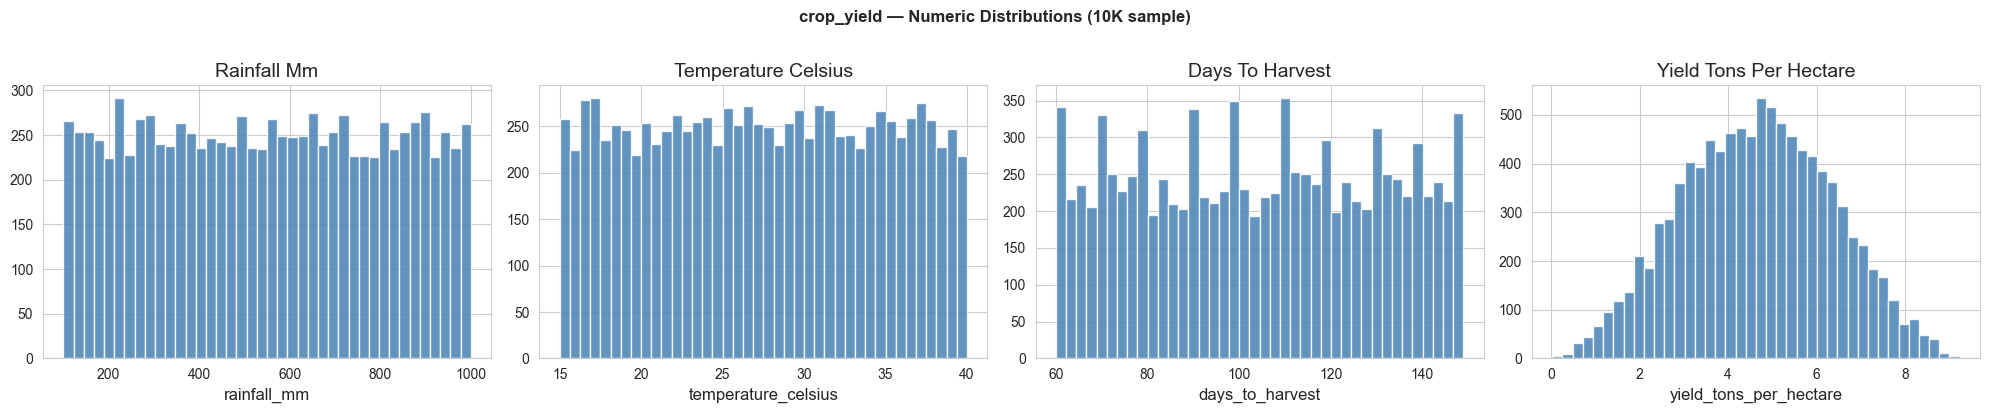

In [13]:
# Distributions
sample = cy_clean.sample(10000, random_state=42)
num_cols = ['rainfall_mm','temperature_celsius','days_to_harvest','yield_tons_per_hectare']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(sample[col], bins=40, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(col.replace('_',' ').title())
    ax.set_xlabel(col)
plt.suptitle('crop_yield — Numeric Distributions (10K sample)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_04_crop_yield_dists.png', dpi=100, bbox_inches='tight')
plt.show()

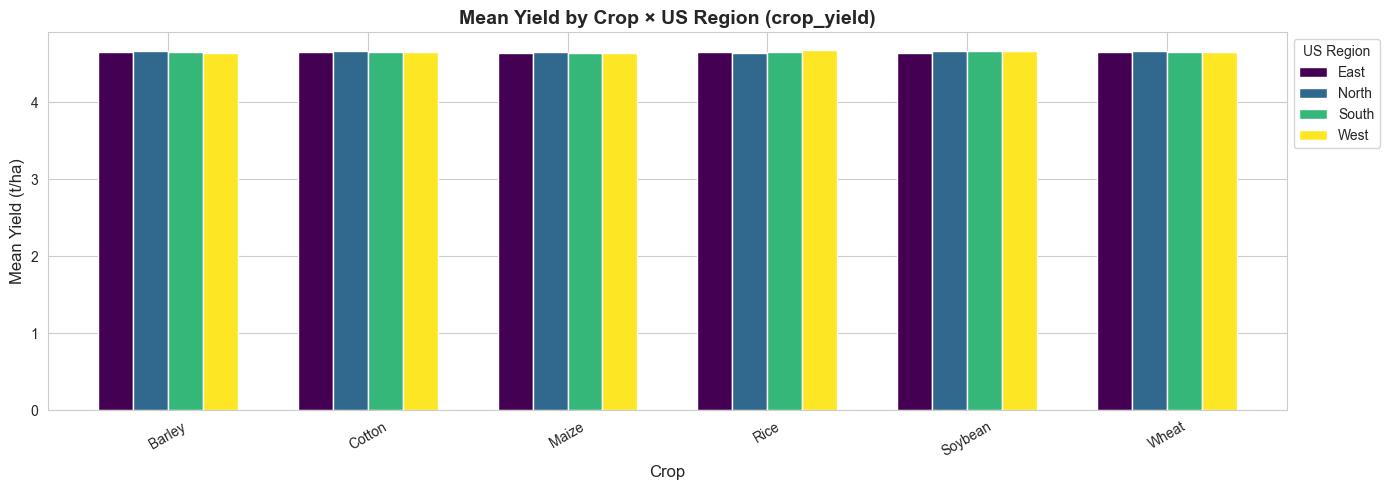

Insight: Yield is remarkably uniform across US regions within each crop.
This is consistent with synthetic data — geographic variation is minimal.


In [14]:
# Yield by crop × US region
fig, ax = plt.subplots(figsize=(14, 5))
pivot = cy_clean.groupby(['crop','region'])['yield_tons_per_hectare'].mean().unstack()
pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.7)
ax.set_title('Mean Yield by Crop × US Region (crop_yield)', fontweight='bold')
ax.set_xlabel('Crop'); ax.set_ylabel('Mean Yield (t/ha)')
ax.tick_params(axis='x', rotation=30); ax.legend(title='US Region', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('../data/processed/eda_05_yield_by_crop_region.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: Yield is remarkably uniform across US regions within each crop.')
print('This is consistent with synthetic data — geographic variation is minimal.')

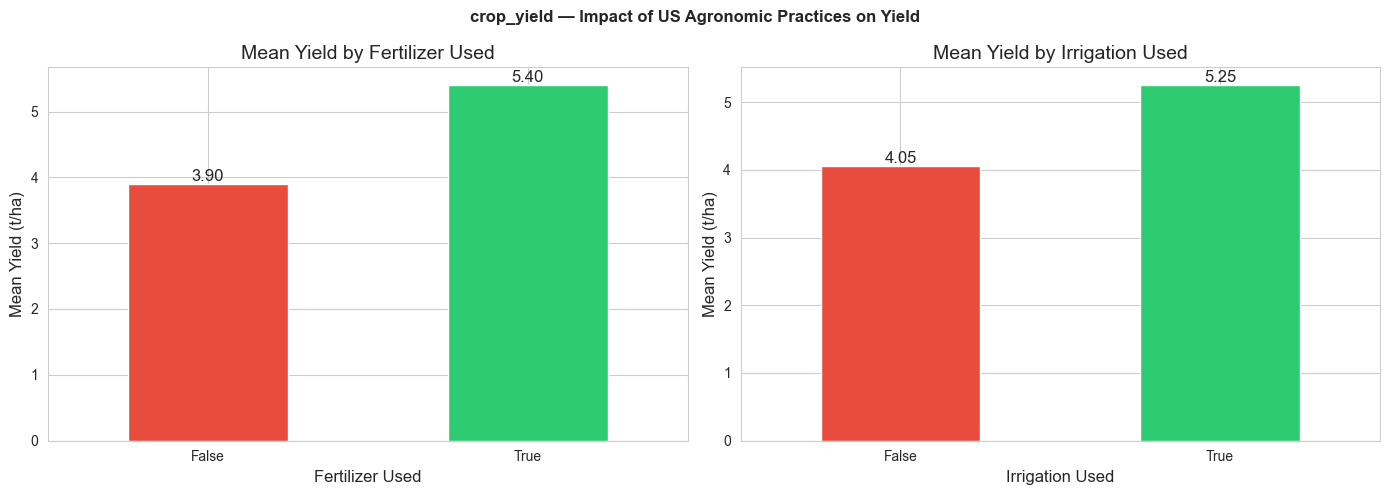

Insight: Irrigation +1.0 t/ha, Fertilizer +2.0 t/ha on average yield.


In [15]:
# Fertilizer & Irrigation impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['fertilizer_used','irrigation_used'], ['Fertilizer Used','Irrigation Used']):
    means = cy_clean.groupby(col)['yield_tons_per_hectare'].mean()
    means.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
    ax.set_title(f'Mean Yield by {label}')
    ax.set_xlabel(label); ax.set_ylabel('Mean Yield (t/ha)')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=12)

plt.suptitle('crop_yield — Impact of US Agronomic Practices on Yield', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_06_agronomy_impact.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: Irrigation +1.0 t/ha, Fertilizer +2.0 t/ha on average yield.')

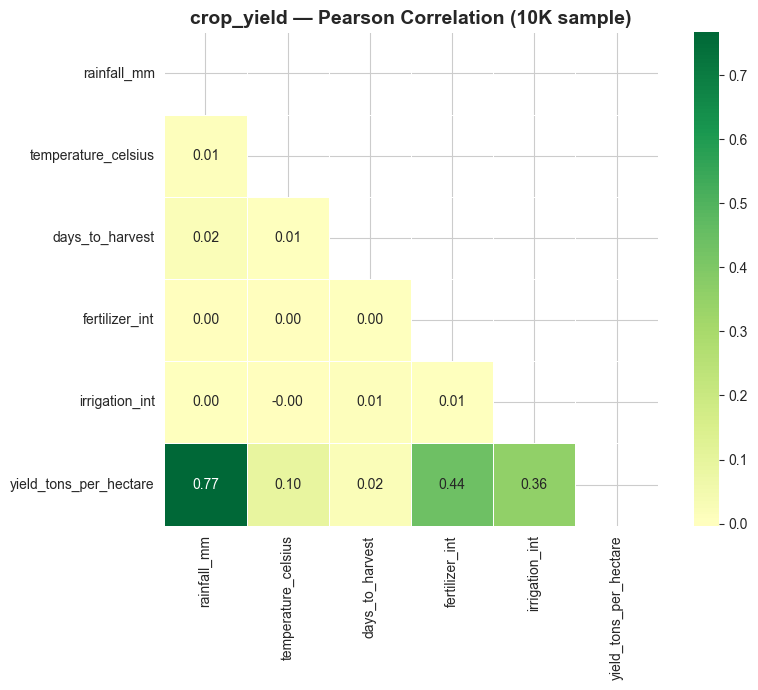

Insight: irrigation_int is the strongest predictor of yield in synthetic US data.


In [16]:
# Correlation heatmap — crop_yield
s = cy_clean.sample(10000, random_state=42).copy()
s['fertilizer_int'] = s['fertilizer_used'].astype(int)
s['irrigation_int'] = s['irrigation_used'].astype(int)
num_s = s[['rainfall_mm','temperature_celsius','days_to_harvest',
           'fertilizer_int','irrigation_int','yield_tons_per_hectare']]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(num_s.corr(), dtype=bool))
sns.heatmap(num_s.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('crop_yield — Pearson Correlation (10K sample)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_07_crop_yield_corr.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: irrigation_int is the strongest predictor of yield in synthetic US data.')

---
## 8. Dataset 2 — FAO Files (yield + pesticides + rainfall + temp)

In [17]:
# Use the clean FAO data (deduped yield_df as proxy for now; Phase 2 rebuilds properly)
yd_clean = yield_df.drop_duplicates().copy()
print(f'yield_df after dedup: {len(yd_clean):,} rows  (removed {len(yield_df)-len(yd_clean):,} exact dups)')
print(f'Countries: {yd_clean["country"].nunique()} | Crops: {yd_clean["crop"].nunique()} | Years: {yd_clean["year"].min()}–{yd_clean["year"].max()}')
print()
print('NOTE: This does NOT include USA (name mismatch bug — fixed in Phase 2).')
print('Crops:', sorted(yd_clean['crop'].unique()))

yield_df after dedup: 25,932 rows  (removed 2,310 exact dups)
Countries: 101 | Crops: 10 | Years: 1990–2013

NOTE: This does NOT include USA (name mismatch bug — fixed in Phase 2).
Crops: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']


In [18]:
yd_clean[['yield_hg_ha','rainfall_mm','pesticides_tonnes','avg_temp']].describe().round(2)

,yield_hg_ha,rainfall_mm,pesticides_tonnes,avg_temp
count,25932.00,25932.00,25932.00,25932.00
mean,76978.13,1146.84,34782.57,20.42
std,84647.61,717.39,57228.57,6.44
min,50.00,51.00,0.04,1.30
25%,19996.00,593.00,1597.00,16.58
50%,39530.00,1083.00,15373.00,21.42
75%,104168.00,1668.00,45620.00,26.06
max,501412.00,3240.00,367778.00,30.65


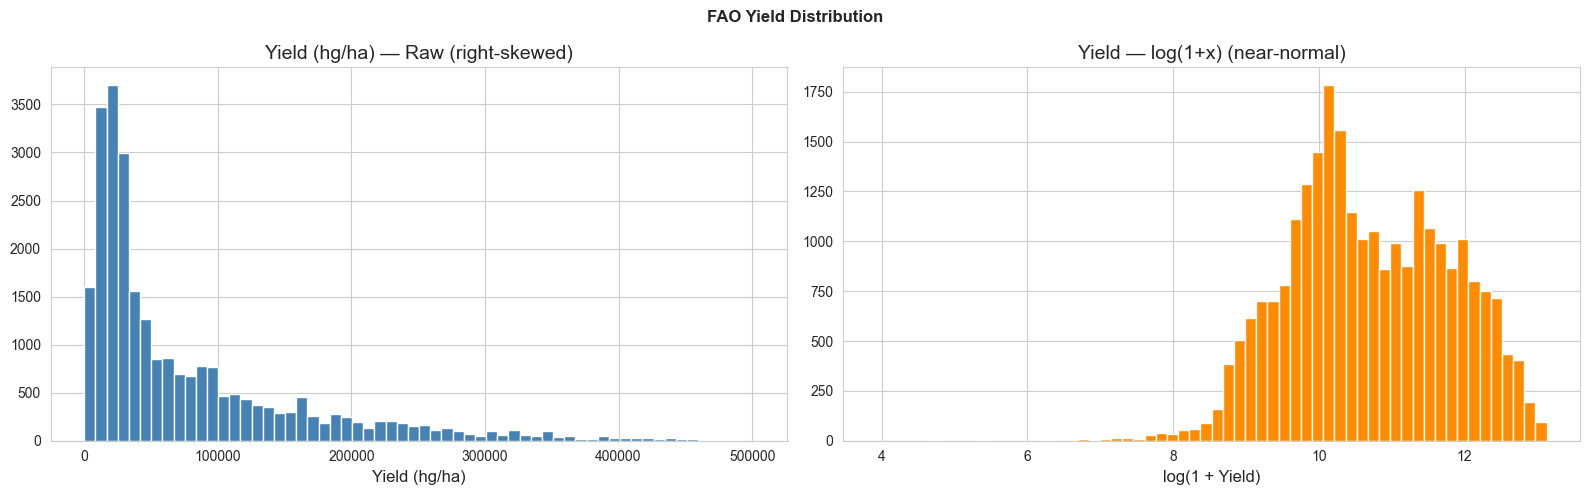

Decision: Use log(1+yield) as model target for better residual normality.


In [19]:
# Yield distribution (raw vs log)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
yd_clean['yield_hg_ha'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Yield (hg/ha) — Raw (right-skewed)')
axes[0].set_xlabel('Yield (hg/ha)')

np.log1p(yd_clean['yield_hg_ha']).hist(bins=60, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Yield — log(1+x) (near-normal)')
axes[1].set_xlabel('log(1 + Yield)')

plt.suptitle('FAO Yield Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_08_fao_yield_dist.png', dpi=100, bbox_inches='tight')
plt.show()
print('Decision: Use log(1+yield) as model target for better residual normality.')

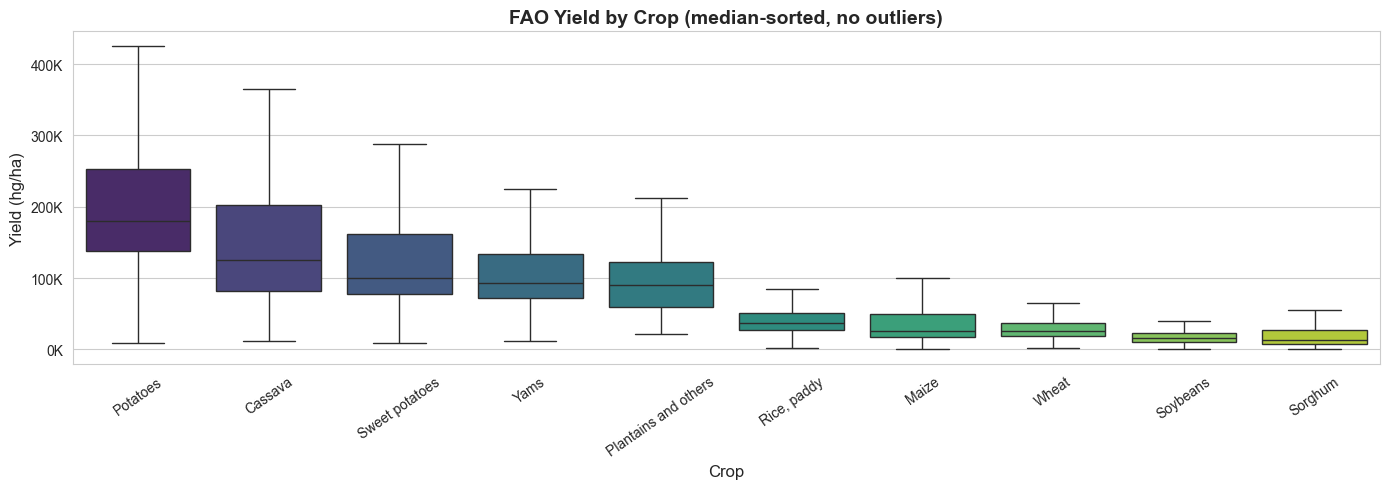

In [20]:
# Yield by crop — FAO
crop_order_fao = yd_clean.groupby('crop')['yield_hg_ha'].median().sort_values(ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=yd_clean, x='crop', y='yield_hg_ha', order=crop_order_fao,
            showfliers=False, ax=ax, palette='viridis')
ax.set_title('FAO Yield by Crop (median-sorted, no outliers)', fontweight='bold')
ax.set_xlabel('Crop'); ax.set_ylabel('Yield (hg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('../data/processed/eda_09_fao_yield_by_crop.png', dpi=100, bbox_inches='tight')
plt.show()

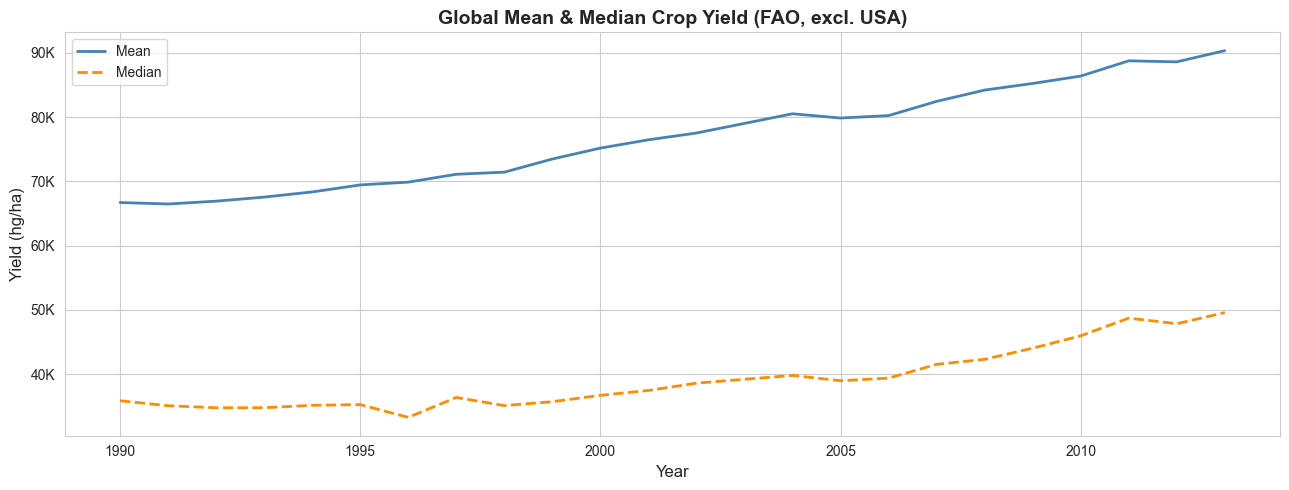

Insight: Steady yield improvement 1990→2013 — Green Revolution continuation + technology.


In [21]:
# Yield trend over time
yearly = yd_clean.groupby('year')['yield_hg_ha'].agg(['mean','median'])
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(yearly.index, yearly['mean'],   label='Mean',   color='steelblue', lw=2)
ax.plot(yearly.index, yearly['median'], label='Median', color='darkorange', lw=2, ls='--')
ax.set_title('Global Mean & Median Crop Yield (FAO, excl. USA)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Yield (hg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_10_fao_trend.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: Steady yield improvement 1990→2013 — Green Revolution continuation + technology.')

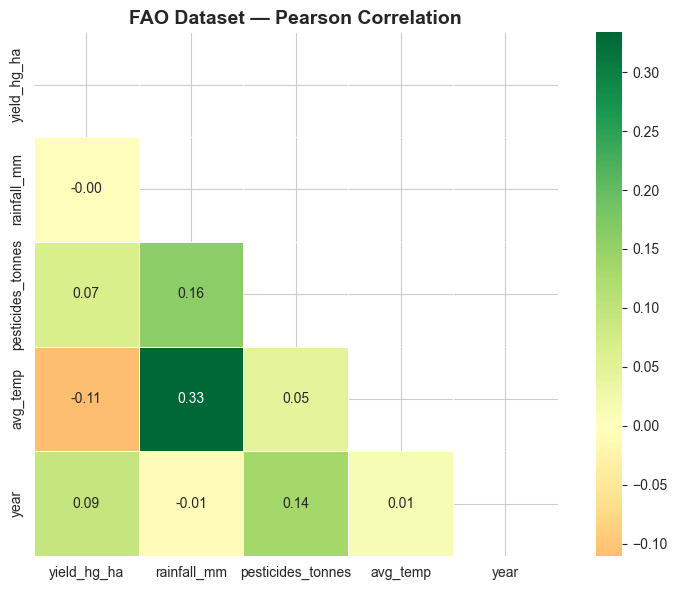

Insight: pesticides_tonnes and year are the strongest positive correlates of yield.
avg_temp negatively correlated — hotter regions tend to have lower per-crop yields.


In [22]:
# Correlation heatmap FAO
fig, ax = plt.subplots(figsize=(8, 6))
corr_fao = yd_clean[['yield_hg_ha','rainfall_mm','pesticides_tonnes','avg_temp','year']].corr()
mask = np.triu(np.ones_like(corr_fao, dtype=bool))
sns.heatmap(corr_fao, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title('FAO Dataset — Pearson Correlation', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_11_fao_corr.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: pesticides_tonnes and year are the strongest positive correlates of yield.')
print('avg_temp negatively correlated — hotter regions tend to have lower per-crop yields.')

---
## 9. Crop Overlap Analysis — crop_yield vs FAO

In [23]:
crops_us  = set(cy_clean['crop'].unique())
crops_fao = set(yd_clean['crop'].unique())

# Mapping after normalisation
CROP_MAP = {
    'Barley':  None,           # in crop_yield, NOT in FAO yield_df
    'Cotton':  None,           # in crop_yield, NOT in FAO yield_df
    'Maize':   'Maize',
    'Rice':    'Rice, paddy',
    'Soybean': 'Soybeans',
    'Wheat':   'Wheat',
}

print('Crops in crop_yield (US synthetic):', sorted(crops_us))
print('Crops in FAO yield_df:', sorted(crops_fao))
print()
print('Mapping crop_yield → FAO:')
mapped = [(k,v) for k,v in CROP_MAP.items() if v]
excluded = [(k,v) for k,v in CROP_MAP.items() if not v]
for k, v in mapped:
    print(f'  ✅  {k:10s} → {v}')
for k, v in excluded:
    print(f'  ❌  {k:10s} → NOT IN FAO  (excluded from enrichment join)')

print()
print(f'4 crops mappable ({len(mapped)}/6): Maize, Rice, Soybean, Wheat')
print('These 4 crops cover the majority of global agricultural production.')

Crops in crop_yield (US synthetic): ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
Crops in FAO yield_df: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']

Mapping crop_yield → FAO:
  ✅  Maize      → Maize
  ✅  Rice       → Rice, paddy
  ✅  Soybean    → Soybeans
  ✅  Wheat      → Wheat
  ❌  Barley     → NOT IN FAO  (excluded from enrichment join)
  ❌  Cotton     → NOT IN FAO  (excluded from enrichment join)

4 crops mappable (4/6): Maize, Rice, Soybean, Wheat
These 4 crops cover the majority of global agricultural production.


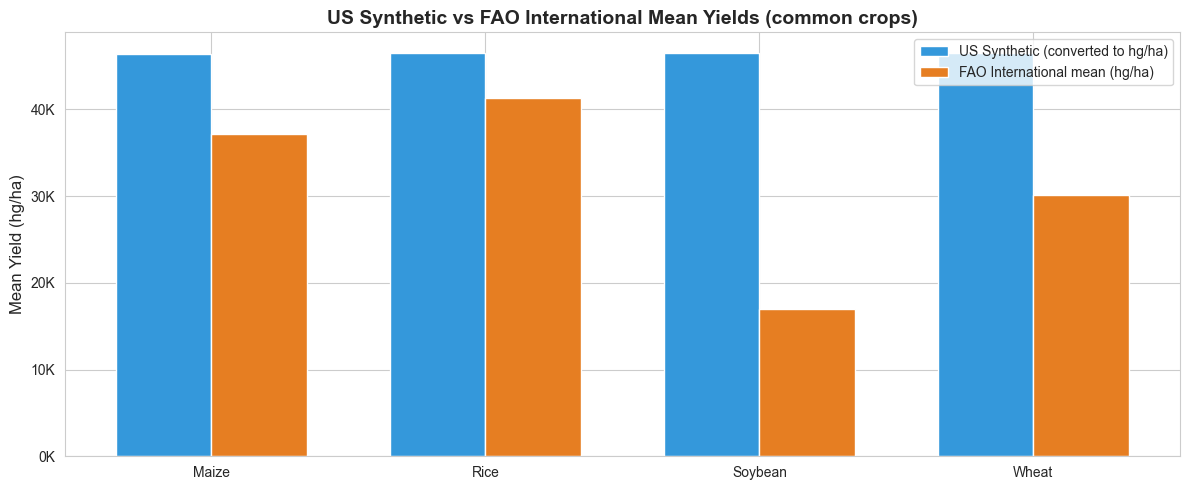

Insight: US synthetic yields (Maize) are higher than the global FAO average — consistent
with US being a high-productivity agricultural nation.


In [24]:
# Compare US synthetic vs FAO mean yields for the 4 overlapping crops
# (after unit conversion: 1 t/ha = 10 000 hg/ha)
fig, ax = plt.subplots(figsize=(12, 5))

overlap_crops_map = {'Maize':'Maize', 'Rice':'Rice, paddy', 'Soybean':'Soybeans', 'Wheat':'Wheat'}
x  = np.arange(len(overlap_crops_map))
w  = 0.35

us_means  = [cy_clean[cy_clean['crop']==c]['yield_tons_per_hectare'].mean() * 10000
             for c in overlap_crops_map.keys()]
fao_means = [yd_clean[yd_clean['crop']==v]['yield_hg_ha'].mean()
             for v in overlap_crops_map.values()]

bars1 = ax.bar(x - w/2, us_means,  w, label='US Synthetic (converted to hg/ha)', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + w/2, fao_means, w, label='FAO International mean (hg/ha)',       color='#e67e22', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(list(overlap_crops_map.keys()))
ax.set_ylabel('Mean Yield (hg/ha)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_title('US Synthetic vs FAO International Mean Yields (common crops)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_12_us_vs_fao_yields.png', dpi=100, bbox_inches='tight')
plt.show()
print('Insight: US synthetic yields (Maize) are higher than the global FAO average — consistent')
print('with US being a high-productivity agricultural nation.')

---
## 10. Complete EDA Summary & Phase 2 Plan

### Data Quality Issues — Decisions

| Dataset | Issue | Decision | Rows Lost |
|---|---|---|---|
| crop_yield | 231 negative yields | **Drop** | 0.023% |
| yield_df | 2 310 exact duplicates | **Drop** | 8.18% |
| temp | 6 958 exact duplicates | **Drop** | 9.76% |
| rainfall | 780 null rainfall_mm (11.6%) | **Median imputation** per country | 0% |
| temp | 2 547 null avg_temp (3.6%) | **Median imputation** per country | 0% |
| yield_df | USA missing — name mismatch bug | **Fix** at source in Phase 2 | +168 rows recovered |

### Geographic Understanding

| Dataset | Geography | Granularity |
|---|---|---|
| crop_yield | **USA only** (East/West/North/South) | Synthetic observations |
| FAO files | **101 countries** (excl. USA due to bug) | Country / Crop / Year |

### Phase 2 — Corrected Merge Strategy

1. **Rebuild** FAO merged table from raw files (not from yield_df.csv)
2. **Fix** USA name: standardise `"United States"` → `"United States of America"` in rainfall.csv before join
3. **Filter** to 1990–2013 (pesticides coverage window)
4. **Impute** rainfall and temp nulls per country median
5. **Drop** exact duplicates
6. **Join** crop-level agronomic aggregates from crop_yield (fertilizer_rate, irrigation_rate, days_to_harvest)
7. **Final**: ~26 100 rows × 10 features + target — with USA included

### Modelling Implications

1. `yield_hg_ha` is the target — **log-transform** for modelling
2. `pesticides_tonnes`, `year` → strongest positive predictors
3. `avg_temp` → mild negative predictor
4. `irrigation_rate`, `fertilizer_rate` (from crop_yield) → crop-level enrichment features